# Goals
- to explore the reason the squared error loss is not appropriate for logistic regression
- to explore the logistic loss function

In [1]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
def plt_logistic_cost(X, y):
    """Plot Logistic Cost"""
    wx, by = np.meshgrid(np.linspace(-6, 12, 50), np.linspace(0, -20, 40))
    points = np.c_[wx.ravel(), by.ravel()]
    cost = np.zeros(points.shape[0], dtype = np.longdouble)

    for i in range(points.shape[0]):
        w, b = points[i]
        cost[i] = compute_cost_matrix(X.reshape(-1, 1), y, w, b, logistic = True, safe = True)
    cost = cost.reshape(wx.shape)

    fig = plt.figure(figsize = (9, 5))
    fig.canvas.toolbar_visible = False
    fig.canvas.header_visible = False
    fig.canvas.footer_visible = False

    ax = fig.add_subplot(1, 2, 1, projection = '3d')
    ax.plot_surface(wx, by, cost, alpha = 0.6, cmap = cm.jet,)
    ax.set_xlabel('w')
    ax.set_ylabel('b')
    ax.set_zlabel("Cost", rotation = 90)
    ax.set_title("Logistic Cost vs (w, b)")
    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

    ax = fig.add_subplot(1, 2, 2, projection = '3d')
    ax.plot_surface(wx, by, np.log(cost), alpha = 0.6, cmap = cm.jet, )

    ax.set_xlabel('w')
    ax.set_ylabel('b')
    ax.set_zlabel('\nlog(Cost)')
    ax.set_title('log(Cost) vs (w, b)')
    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

    plt.show()
    return cost

In [18]:
def plt_two_logistic_loss_curves():
    """Plots the Logistic Loss"""
    fig, ax = plt.subplots(1, 2, figsize = (6, 3), sharey = True)
    fig.canvas.toolbar_visible = False
    fig.canvas.header_visible = False
    fig.canvas.footer_visible = False

    x = np.linspace(0.01, 1 - 0.01, 20)

    ax[0].plot(x, -np.log(x))
    ax[0].text(0.5, 4.0, "y = 1")
    ax[0].set_ylabel("Loss")
    ax[0].set_xlabel(r"$f_{w,b}(x)$")
    ax[1].plot(x,-np.log(1-x))
    ax[1].text(0.5, 4.0, "y = 0")
    ax[1].set_xlabel(r"$f_{w,b}(x)$")

    ax[0].annotate("Prediction \nMatches \nTarget",
        xy = [1, 0], xycoords = 'data',
                   xytext = [-10, 30], textcoords = 'offset points',
                   ha = 'right', va = 'center',
                   arrowprops = {
                       'arrowstyle' : '->',
                       'color' : 'm', 'lw' : 3
                   },
    )
    ax[0].annotate("Loss increases as prediction \ndiffers from target",
        xy = [0.1, -np.log(0.1)], xycoords = 'data',
                   xytext = [10, 30], textcoords = 'offset points',
                   ha = 'left', va = 'center',
                   arrowprops = {
                       'arrowstyle' : '->',
                       'color' : 'm', 'lw' : 3
                   },
    )

    ax[1].annotate("Prediction \nMatches \nTarget",
        xy = [0, 0], xycoords = 'data',
                   xytext = [10, 30], textcoords = 'offset points',
                   ha = 'left', va = 'center',
                   arrowprops = {
                       'arrowstyle' : '->',
                       'color' : 'm', 'lw' : 3
                   },
    )
    ax[1].annotate("Loss increases as prediction \ndiffers from target",
        xy = [0.9, -np.log(1 - 0.9)], xycoords = 'data',
                   xytext = [-10, 30], textcoords = 'offset points',
                   ha = 'right', va = 'center',
                   arrowprops = {
                       'arrowstyle' : '->',
                       'color' : 'm', 'lw' : 3
                   },
    )

    plt.suptitle("Loss Curves for Two Categorical Target Values")
    plt.tight_layout()
    plt.show()

In [4]:
def plt_simple_example(x, y):
    """Plots tumor data"""
    pos = y == 1
    neg = y == 0

    fig, ax = plt.subplots(1, 1, figsize = (5, 3))
    fig.canvas.toolbar_visible = False
    fig.canvas.header_visible = False
    fig.canvas.footer_visible = False

    ax.scatter(x[pos], y[pos], marker = 'x', s = 80, c = 'r', label = 'malignant')
    ax.scatter(x[neg], y[neg], marker = 'o', s = 100, c = 'b', label = 'benign', facecolors = 'none', lw = 3)

    ax.set_ylim(-0.75, 1.1)
    ax.set_ylabel('y')
    ax.set_xlabel('Tumor Size')
    ax.legend(loc = 'lower right')
    ax.set_title("Example of Logistic Regression on Categorical Data")
    plt.show()

In [5]:
def plt_logistic_squared_error(X, y):
    """Plots Logistic Squared Error"""
    wx, by = np.meshgrid(np.linspace(-6, 12, 50), np.linspace(10, -20, 40))
    points = np.c_[wx.ravel(), by.ravel()]
    cost = np.zeros(points.shape[0])

    for i in range(points.shape[0]):
        w, b = points[i]
        cost[i] = compute_cost_logistic_sq_err(X.reshape(-1, 1), y, w, b)
    cost = cost.reshape(wx.shape)

    fig = plt.figure()
    fig.canvas.toolbar_visible = False
    fig.canvas.header_visible = False
    fig.canvas.footer_visible = False

    ax = fig.add_subplot(1, 1, 1, projection = '3d')
    ax.plot_surface(wx, by, cost, alpha = 0.6, cmap = cm.jet, )
    ax.set_xlabel('w')
    ax.set_ylabel('b')
    ax.set_zlabel('Cost', rotation = 90)
    ax.set_title('Logistic Squared Error Cost vs (w, b)')
    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

In [12]:
def compute_cost_logistic_sq_err(X, y, w, b):
    """
    Compute squared error loss on logistic data
    Args:
        X (ndarray) : Shape(m, n) Matrix of examples with multiple features
        w (ndarray) : Shape(n) Parameter for prediction
        b (scalar) : Parameter for prediction
    Returns:
        cost (scalar) : Cost
    """
    m = X.shape[0]
    cost = 0.0

    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_wb_i = sigmoid(z_i)
        cost += (f_wb_i - y[i]) ** 2
    cost /= (2 * m)

    return np.squeeze(cost)

In [7]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    g = 1.0 / (1.0 + np.exp(-z))

    return g

In [8]:
def compute_cost_matrix(X, y, w, b, logistic = False, lambda_ = 0, safe = True):
    """
    Computes cost using matrices
    Args:
        X: (ndarray Shape (m, n)) Matrix of examples
        y: (ndarray Shape (m, ) or (m, 1)) target value of each example
        w: (ndarray Shape (n, ) or (n, )) Values of parameters
        b: (scalar) Values of parameters
        verbose (Boolean) If true, print out intermediate value f_wb
    Returns:
        total_cost: (scalar) Cost
    """

    m = X.shape[0]
    y = y.reshape(-1, 1) #ensure 2d
    w = w.reshape(-1, 1) #ensure 2d

    if logistic:
        if safe: #safe from overflow
            z = X @ w + b
            cost = -(y * z) + log_1pexp(z)
            cost = np.sum(cost) / m
        else:
            f = sigmoid(X @ w + b)
            cost = (1 / m) * (np.dot(-y.T, np.log(f)) - np.dot((1-y).T, np.lof(1 - f)))
            cost = cost[0, 0]
    else:
        f = X @ w + b
        cost = (1 / (2 * m)) * np.sum((f - y) ** 2)

    reg_cost = (lambda_ / (2 * m)) * np.sum(w ** 2)
    total_cost = cost + reg_cost

    return total_cost

In [9]:
def log_1pexp(x, maximum = 20):
    """
    Approximate log(1 + exp^x)
    Args:
        x: (ndarray Shape (n, 1) or (n, )) input
    Returns:
        out: (ndarray Shape maches x) output ~= np.log(1 + exp(x))
    """

    out = np.zeros_like(x, dtype = float)
    i = x <= maximum
    ni = np.logical_not(i)

    out[i] = np.log(1 + np.exp(x[i]))
    out[ni] = x[ni]

    return out

# Training Data

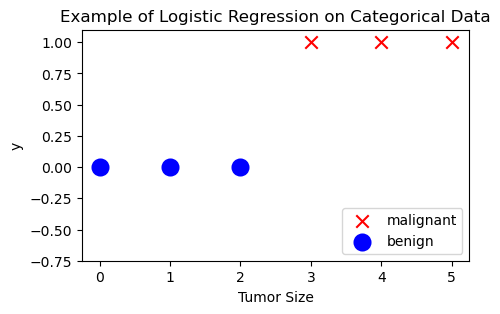

In [10]:
x_train = np.array([0, 1, 2, 3, 4, 5], dtype = np.longdouble)
y_train = np.array([0, 0, 0, 1, 1, 1], dtype = np.longdouble)
plt_simple_example(x_train, y_train)

Let's get a surface plot of the cost using squared error cost.

$$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2 $$

where,

$$f_{w,b}(x^{(i)}) = sigmoid(wx^{(i)} + b )$$

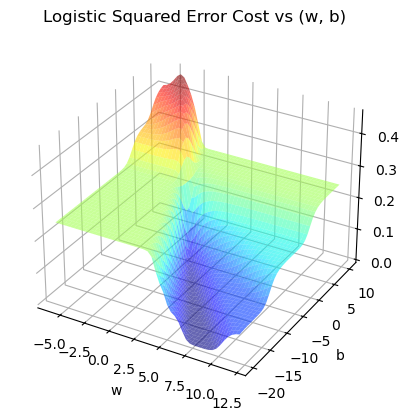

In [13]:
plt.close('all')
plt_logistic_squared_error(x_train, y_train)
plt.show()

# Logistic Loss Function
- $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ is the cost of a single data point, which is:
\begin{equation}
  loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = \begin{cases}
    - \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) & \text{if $y^{(i)}=1$}\\
    - \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) & \text{if $y^{(i)}=0$}
  \end{cases}
\end{equation}

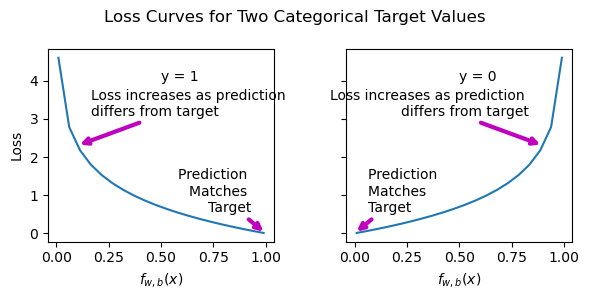

In [19]:
plt.close('all')
plt_two_logistic_loss_curves()

The loss function above can be rewritten as:
$$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)$$

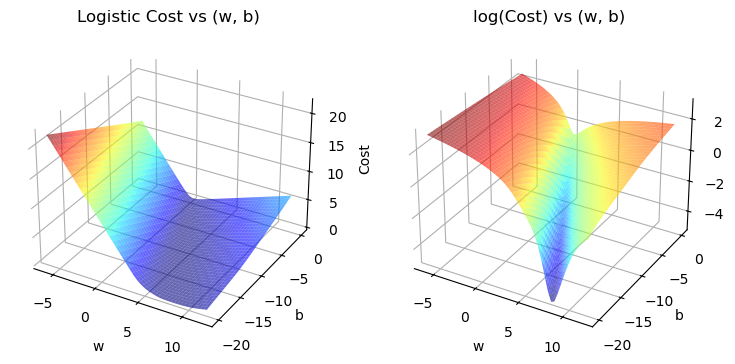

[[12.11593817 11.38142824 10.64700033 ...  5.74817973  5.93185254
   6.11552555]
 [12.3348674  11.60028381 10.86574947 ...  5.53992579  5.72359816
   5.90727087]
 [12.56404064 11.82941284 11.0948146  ...  5.34185036  5.525522
   5.7091942 ]
 ...
 [21.48717949 20.75248561 20.01779173 ...  0.59747467  0.71753235
   0.83885368]
 [21.74358974 21.00889587 20.27420199 ...  0.51504527  0.63352046
   0.75404807]
 [22.         21.26530612 20.53061225 ...  0.43456238  0.55050217
   0.66974757]]


In [20]:
plt.close('all')
cst = plt_logistic_cost(x_train, y_train)
plt.show()

print(cst)

In [22]:
import pandas as pd

In [25]:
df = pd.DataFrame(cst)

In [26]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,12.115938,11.381428,10.647000,9.912691,9.178555,8.444669,7.711150,6.978168,6.245984,5.515000,...,4.462491,4.646156,4.829824,5.013493,5.197164,5.380835,5.564507,5.748180,5.931853,6.115526
1,12.334867,11.600284,10.865749,10.131287,9.396928,8.662720,7.928735,7.195077,6.461907,5.729479,...,4.254255,4.437914,4.621577,4.805244,4.988913,5.172583,5.356254,5.539926,5.723598,5.907271
2,12.564041,11.829413,11.094815,10.360259,9.625766,8.891365,8.157097,7.423027,6.689254,5.955933,...,4.056208,4.239858,4.423514,4.607176,4.790842,4.974510,5.158180,5.341850,5.525522,5.709194
3,12.801737,12.067083,11.332447,10.597836,9.863262,9.128744,8.394306,7.659987,6.925847,6.191981,...,3.866666,4.050300,4.233945,4.417600,4.601260,4.784924,4.968591,5.152260,5.335931,5.519602
4,13.045853,12.311183,11.576523,10.841879,10.107257,9.372668,8.638128,7.903659,7.169298,6.435102,...,3.683554,3.867161,4.050788,4.234429,4.418081,4.601739,4.785401,4.969068,5.152736,5.336406
